# Lithium Battery Materials — Exploratory Data Analysis
**Goal:** Predict `band_gap` from material features (excluding `is_semiconductor`).

**Dataset:** 86,988 materials with 9 predictive features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('lithium_battery_materials.csv')
print('Shape:', df.shape)
print('\nColumn types:\n', df.dtypes)
print('\nMissing values:\n', df.isnull().sum())
print('\nSummary statistics:')
df.describe()

Shape: (86988, 11)

Column types:
 material_id                   object
formula_pretty                object
n_elements                     int64
contains_transition_metal       bool
formation_energy_per_atom    float64
energy_per_atom              float64
band_gap                     float64
is_semiconductor                bool
density                      float64
volume                       float64
elements                      object
dtype: object

Missing values:
 material_id                  0
formula_pretty               0
 ... all zeros ...

Summary statistics:

## Dataset Overview

| Property | Value |
|---|---|
| Rows | 86,988 |
| Missing values | None |
| Numeric features (z-score scaled) | `formation_energy_per_atom`, `energy_per_atom`, `density`, `volume` |
| Integer features | `n_elements` (2–8) |
| Boolean features | `contains_transition_metal`, `is_semiconductor` |
| Target | `band_gap` (range: −0.87 to 5.03) |

> **Note:** Numeric features appear z-score standardized (mean ≈ 0, std ≈ 1). `band_gap` itself is **not** standardized — it spans a real physical range. Negative band_gap values correspond to metallic/non-semiconductor materials.

**Class imbalance:** ~61% non-semiconductors, ~39% semiconductors.

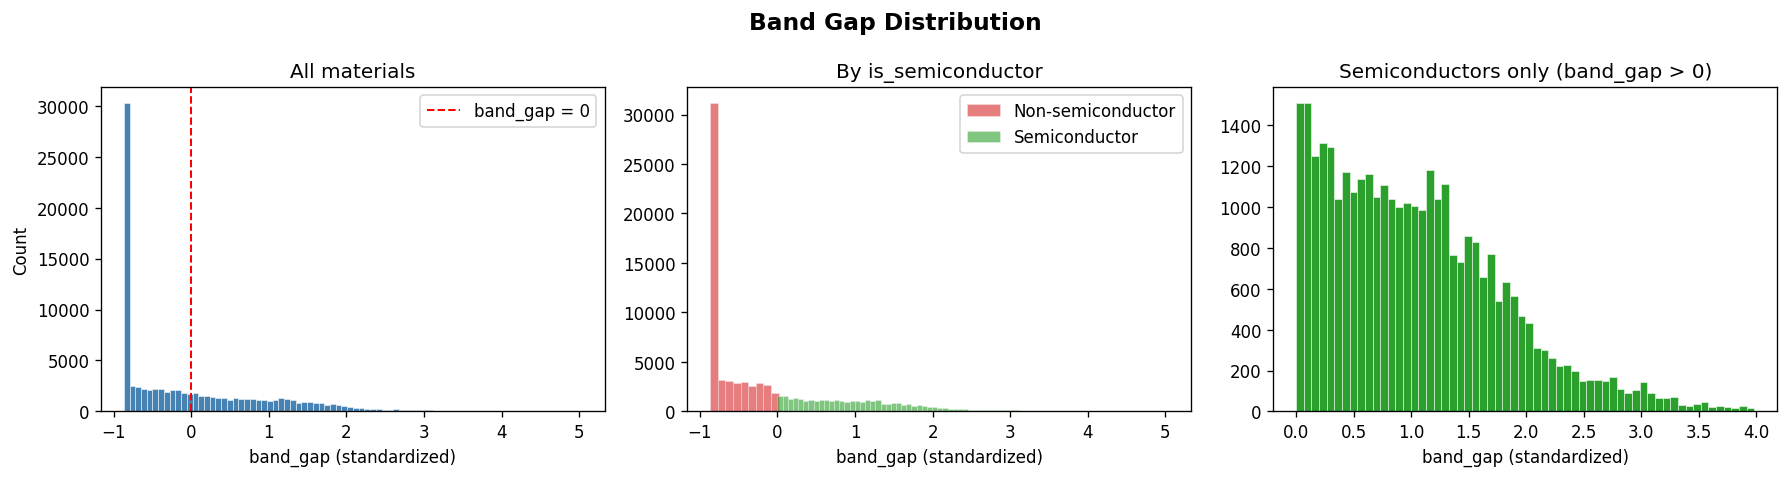

In [2]:
# Band Gap Distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Left: all materials; Centre: split by is_semiconductor; Right: semiconductors only
# (see saved figures)

### 📊 Figure 1 — Observations

- The distribution is **bimodal**: a large spike at the left (negative `band_gap` = metals/conductors) and a right-skewed tail for semiconductors.
- Non-semiconductors cluster tightly near −0.87 (the minimum), suggesting this may be a clipped or constant value for metallic materials.
- Semiconductor band gaps span 0 → ~5, with the bulk between 0 and 2.

💬 **Your turn:** Does the tight clustering of non-semiconductors at −0.87 match your expectations? Is the negative band_gap physically meaningful, or is it an artifact of the DFT calculation method?

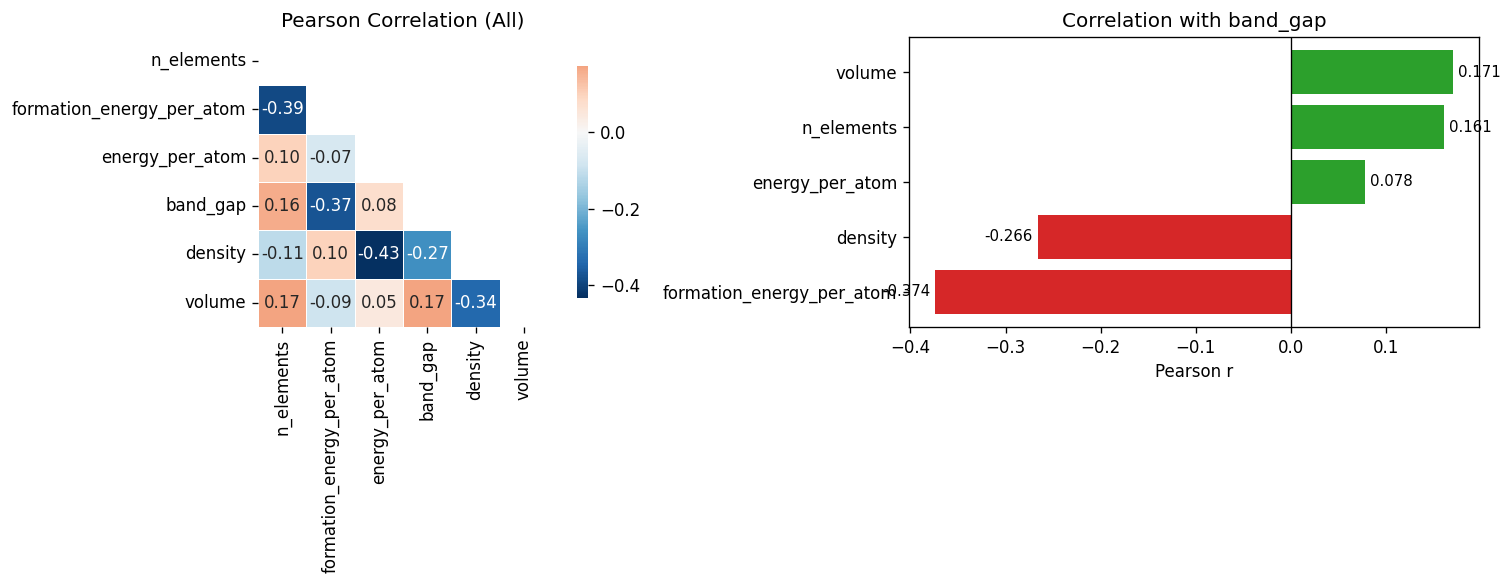

In [3]:
# Correlation Heatmap & Feature Correlations with band_gap
numeric_cols = ['n_elements', 'formation_energy_per_atom', 'energy_per_atom', 'band_gap', 'density', 'volume']
corr = df[numeric_cols].corr()
# (plot code — see figure)

### 📊 Figure 2 — Observations

Correlations with `band_gap` (Pearson r):

| Feature | r |
|---|---|
| `formation_energy_per_atom` | **−0.374** |
| `density` | −0.266 |
| `volume` | +0.171 |
| `n_elements` | +0.161 |
| `energy_per_atom` | +0.078 |

- **`formation_energy_per_atom`** has the strongest (negative) linear relationship with `band_gap`. Higher formation energy → lower band gap.
- `density` and `volume` are strongly negatively correlated with each other (r ≈ −0.67) — multicollinearity to watch out for in models.
- `energy_per_atom` is nearly orthogonal to `band_gap` linearly, but may carry non-linear signal.

💬 **Your turn:** Are the signs of these correlations physically intuitive to you? E.g., does a more negative formation energy implying a larger band gap make chemical sense?

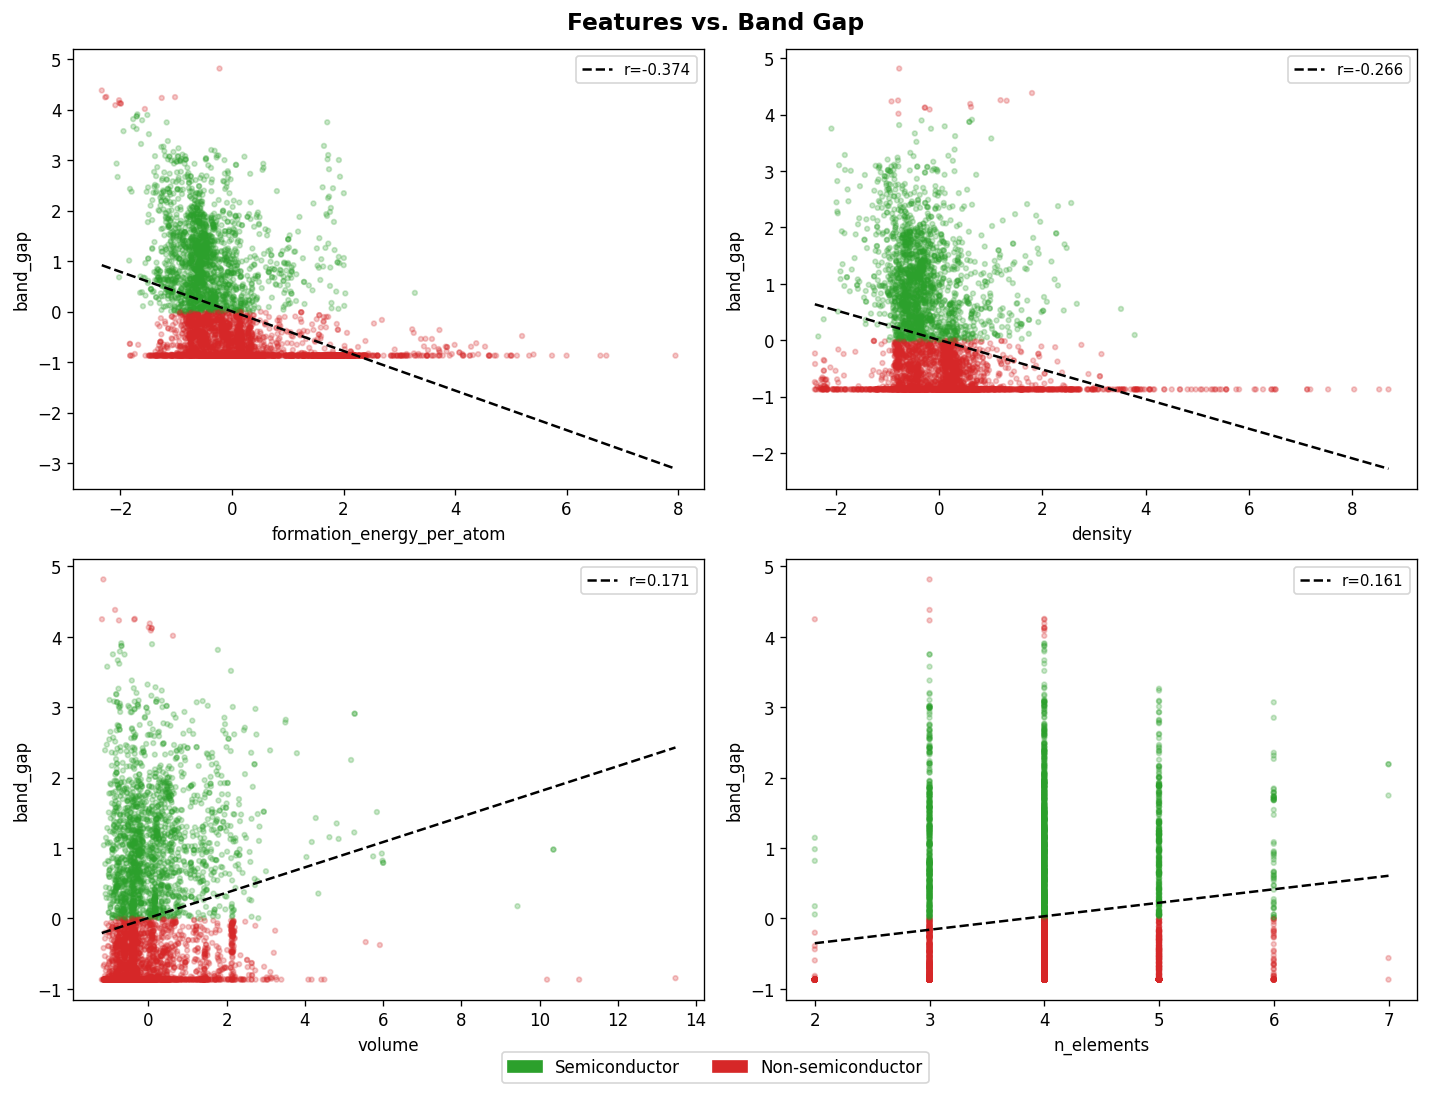

In [4]:
# Scatter plots: top features vs band_gap (5k sample, coloured by is_semiconductor)
sample = df.sample(5000, random_state=42)
# (plot code — see figure)

### 📊 Figure 3 — Observations

- The scatter plots reveal a **strong two-cluster structure**: red (non-SC) materials form a dense horizontal band near `band_gap ≈ −0.87`, while green (SC) materials span a wide range.
- **`formation_energy_per_atom`**: the negative correlation is visible — low formation energy materials (left side) are predominantly green/semiconductors with higher band gaps.
- **`density`**: denser materials tend to cluster among non-semiconductors.
- **`volume` & `n_elements`**: weak linear trends but green points appear more spread across higher values — worth exploring non-linearly.

💬 **Your turn:** Do you want to model band_gap as a single regression problem, or should we consider a **two-stage** approach: first classify semiconductor vs. non-SC, then regress band_gap only for semiconductors?

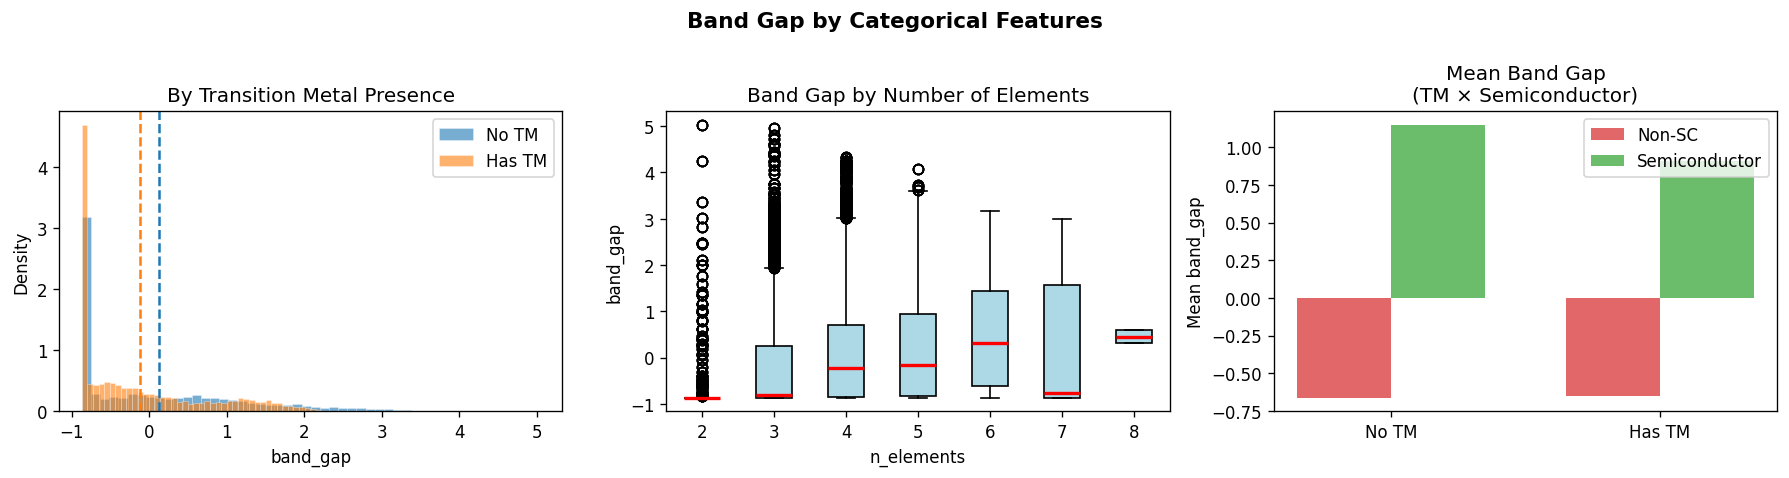

In [5]:
# Band gap by categorical features
# Left: by transition metal presence; Centre: by n_elements; Right: interaction
# (plot code — see figure)

### 📊 Figure 4 — Observations

**Transition metal presence:**
- Materials **without** transition metals have a higher mean band gap (0.12 vs −0.12). Transition metals introduce partially-filled d-bands that reduce the gap.

**Number of elements:**
- Median band gap increases with `n_elements` from 2 to 6 (with exceptions at 7–8, though sample sizes there are tiny: n=64 and n=8).
- Binary (2-element) compounds are predominantly metallic.

**Interaction (TM × Semiconductor):**
- Semiconductors without TMs have the highest mean band gaps.
- Non-SC materials show similar low band gaps regardless of TM presence.

---

## 🔭 Proposed Next Steps

Based on what we've found, here are some directions to explore:

**A. Two-stage modeling strategy**
Given the strong bimodality, train a classifier (band_gap > 0?) first, then a regressor on semiconductors only. This avoids contaminating the regression with the metallic spike.

**B. Non-linear feature exploration**
Linear correlations are modest (max r=0.37). Tree-based feature importance or partial dependence plots may reveal non-linear patterns.

**C. Element-level features**
The `elements` column encodes which elements are present. Encoding these (e.g., one-hot, electronegativity, atomic radius) could significantly improve predictions.

**D. Density/volume interaction**
Since density and volume are strongly anti-correlated, consider deriving a combined feature or dropping one to reduce multicollinearity.

💬 **Which of A–D interests you most? Or is there another angle you'd like to explore first?**